# **Interpretable Machine Learning for Predicting Student Digital Risk: Insights into Screen Time, Supervision, and Online Behavior**

# Background

Students today grow up with constant access to digital devices, social media, and online platforms. While technology supports learning and communication, excessive screen time, online exposure, and weak digital supervision may increase risks such as cyberbullying, inappropriate content exposure, and academic or behavioral issues. Understanding how family background, supervision, digital habits, and online behavior relate to student outcomes is important for promoting safer and healthier digital environments.

# Problem Statement

Build a machine learning model that analyzes student demographic, household, academic, and digital behavior data to predict students’ exposure to online risks, such as cyberbullying and online violence, and identify the factors that contribute most to high digital risk.

## Objectives

1. Predict students’ online risk or exposure level using classification models

2. Identify key factors associated with higher digital risk, including screen time, supervision, and social media usage.

3. Provide insights to support parents, educators, and policymakers in improving digital safety and supervision strategies.

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load the Dataset

In [ ]:
df = pd.read_csv('Juvenile data set.csv')
df.head()

,student_id,age,sex,region,urban_rural,household_income_class,parents_education,family_structure,parental_supervision_level,parent_screen_time_hours,...,substance_exposure,neighborhood_safety_index,stress_level,daily_screen_time_hours,social_media_time_hours,night_phone_use_after_10pm,online_content_risk_level,cyberbullying_exposure_level,juvenile_offense,offense_severity
0,1,16,Male,Region III,Urban,Low,Elementary,Blended family,3,5.6,...,High,6,7,3.8,1.9,Yes,Medium,High,0,NaN
1,2,15,Female,Region I,Urban,Low,High School,Guardian/relative,8,7.7,...,NaN,9,2,4.1,1.8,No,Low,High,0,NaN
2,3,12,Female,Region VIII,Urban,Middle,High School,Guardian/relative,5,6.1,...,High,1,2,5.3,3.1,No,Low,Low,0,NaN
3,4,13,Male,Region VI,Rural,Low,College,Two parents,9,4.5,...,Medium,9,8,5.7,3.2,No,Medium,Low,0,NaN
4,5,13,Male,Region II,Urban,Middle,College,Single parent,2,4.7,...,Medium,4,1,4.4,2.8,No,Medium,Low,0,NaN


# Exploratory Data Analysis

# Target Distribution

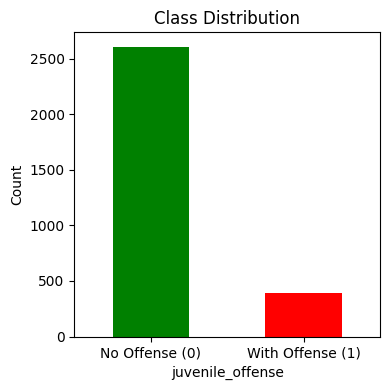

In [ ]:
plt.figure(figsize=(4, 4))

df['juvenile_offense'].value_counts().sort_index().plot(
    kind="bar",
    color=["green", "red"]
)

plt.xticks([0, 1], ["No Offense (0)", "With Offense (1)"], rotation=0)
plt.ylabel("Count")
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

# Data Diagnosis

In [ ]:
rows = []
missing_pct = df.isna().mean().mul(100).round(2)

for col in df.columns:
    s = df[col].dropna()
    n = len(s)
    uniq = s.nunique()
    samples = s.unique()[:10].tolist()

    # numeric check
    s_num = pd.to_numeric(s, errors="coerce")
    is_numeric = (n > 0) and (s_num.notna().mean() > 0.95)

    # identifier check
    is_id = (n > 0) and (uniq >= 0.95 * n)

    # suggested type
    if uniq == 1:
        t = "constant"
    elif is_id:
        t = "identifier"
    elif uniq == 2:
        t = "binary"
    elif is_numeric:
        t = "numeric"
    else:
        t = "categorical"

    # numeric stats
    min_v = max_v = mean_v = None
    if t == "numeric":
        min_v, max_v, mean_v = s_num.min(), s_num.max(), s_num.mean()

    rows.append({
        "Column": col,
        "Unique Values": uniq,
        "Sample Values": samples,
        "Suggested Type": t,
        "Missing %": float(missing_pct[col]),
        "Min": min_v,
        "Max": max_v,
        "Mean": mean_v
    })

diagnosis_df = pd.DataFrame(rows)
diagnosis_df

,Column,Unique Values,Sample Values,Suggested Type,Missing %,Min,Max,Mean
0,student_id,3000,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",identifier,0.00,NaN,NaN,NaN
1,age,6,"[16, 15, 12, 13, 17, 14]",numeric,0.00,12.00,17.0,14.469333
2,sex,2,"[Male, Female]",binary,0.00,NaN,NaN,NaN
3,region,14,"[Region III, Region I, Region VIII, Region VI,...",categorical,0.00,NaN,NaN,NaN
4,urban_rural,2,"[Urban, Rural]",binary,0.00,NaN,NaN,NaN
5,household_income_class,3,"[Low, Middle, High]",categorical,0.00,NaN,NaN,NaN
6,parents_education,4,"[Elementary, High School, College, Postgraduate]",categorical,0.00,NaN,NaN,NaN
7,family_structure,4,"[Blended family, Guardian/relative, Two parent...",categorical,0.00,NaN,NaN,NaN
8,parental_supervision_level,10,"[3, 8, 5, 9, 2, 1, 10, 6, 4, 7]",numeric,0.00,1.00,10.0,5.508333
9,parent_screen_time_hours,61,"[5.6, 7.7, 6.1, 4.5, 4.7, 6.3, 7.2, 4.3, 5.3, ...",numeric,0.00,2.00,8.0,4.987700


In [ ]:
df["substance_exposure"] = df["substance_exposure"].fillna("None")

Insights
1. Academic performance is generally strong but varies widely, with an average grade of 82/100 and scores ranging from 68 to 96 across students.
2. Digital exposure is high for both students and parents, with students averaging 5.7 hours/day of screen time and parents 5 hours, creating a clear angle for analyzing digital behavior impacts.
3. Psychosocial factors sit at moderate levels with meaningful spread, as stress, parental supervision, digital literacy, and neighborhood safety cluster around 5–5.5 on a 10-point scale.
4. Behavioral risk appears present but not prevalent, with juvenile offenses being relatively rare and disciplinary incidents averaging less than one per student per year.
5. Outcome data quality is a major concern, as offense severity is missing in 87% of records, limiting its usefulness for reliable analysis or modeling.

# Features Identification

In [ ]:
# Target
target_col = ["juvenile_offense"]

# Drop (Constants and Identifiers)
drop_col = ["student_id", "offense_severity", "disciplinary_incidents_last_year",
    "cyberbullying_exposure_level", "online_content_risk_level"]

# Categorical Features
cat_cols = ["sex", "urban_rural", "screen_rules_enforced", "night_phone_use_after_10pm",
    "region", "household_income_class", "parents_education", "family_structure",
    "peer_delinquency_exposure"]

# Ordinal Features
ord_cols = ["parental_supervision_level", "parent_digital_literacy_level",
    "neighborhood_safety_index", "stress_level"]

# Numerical Features
num_cols = ["age", "parent_screen_time_hours", "school_attendance_rate", "school_grade_average",
      "daily_screen_time_hours", "social_media_time_hours"]

# Feature Type Conversions

In [ ]:
df_type_converted = df.copy()

# Drop constants + identifiers
df_type_converted = df_type_converted.drop(columns=drop_col, errors="ignore")

# Categorical
for col in cat_cols:
    df_type_converted[col] = df_type_converted[col].astype("category")

# Ordinal + Numerical
for col in ord_cols + num_cols:
    df_type_converted[col] = pd.to_numeric(df_type_converted[col], errors="coerce")

df_type_converted.head()

,age,sex,region,urban_rural,household_income_class,parents_education,family_structure,parental_supervision_level,parent_screen_time_hours,parent_digital_literacy_level,...,school_attendance_rate,school_grade_average,peer_delinquency_exposure,substance_exposure,neighborhood_safety_index,stress_level,daily_screen_time_hours,social_media_time_hours,night_phone_use_after_10pm,juvenile_offense
0,16,Male,Region III,Urban,Low,Elementary,Blended family,3,5.6,3,...,0.71,70.8,Medium,High,6,7,3.8,1.9,Yes,0
1,15,Female,Region I,Urban,Low,High School,Guardian/relative,8,7.7,2,...,0.81,75.7,Low,None,9,2,4.1,1.8,No,0
2,12,Female,Region VIII,Urban,Middle,High School,Guardian/relative,5,6.1,4,...,0.68,70.3,Medium,High,1,2,5.3,3.1,No,0
3,13,Male,Region VI,Rural,Low,College,Two parents,9,4.5,2,...,0.66,88.1,High,Medium,9,8,5.7,3.2,No,0
4,13,Male,Region II,Urban,Middle,College,Single parent,2,4.7,10,...,0.83,81.5,Medium,Medium,4,1,4.4,2.8,No,0


# Correlations

# Categorical Features vs Target

In [ ]:
from scipy.stats import chi2_contingency

alpha = 0.10

cat_results = []
for col in cat_cols:
    table = pd.crosstab(df_type_converted[col], df_type_converted["juvenile_offense"])
    chi2, p, _, _ = chi2_contingency(table)
    cat_results.append({"feature": col, "p_value": p, "decision": "Retain" if p < alpha else "Drop"})

cat_vs_target = pd.DataFrame(cat_results).sort_values("p_value")
cat_vs_target

,feature,p_value,decision
5,household_income_class,0.088467,Retain
4,region,0.115765,Drop
2,screen_rules_enforced,0.122389,Drop
8,peer_delinquency_exposure,0.384041,Drop
6,parents_education,0.400743,Drop
7,family_structure,0.648361,Drop
0,sex,0.720438,Drop
1,urban_rural,0.741425,Drop
3,night_phone_use_after_10pm,0.823098,Drop


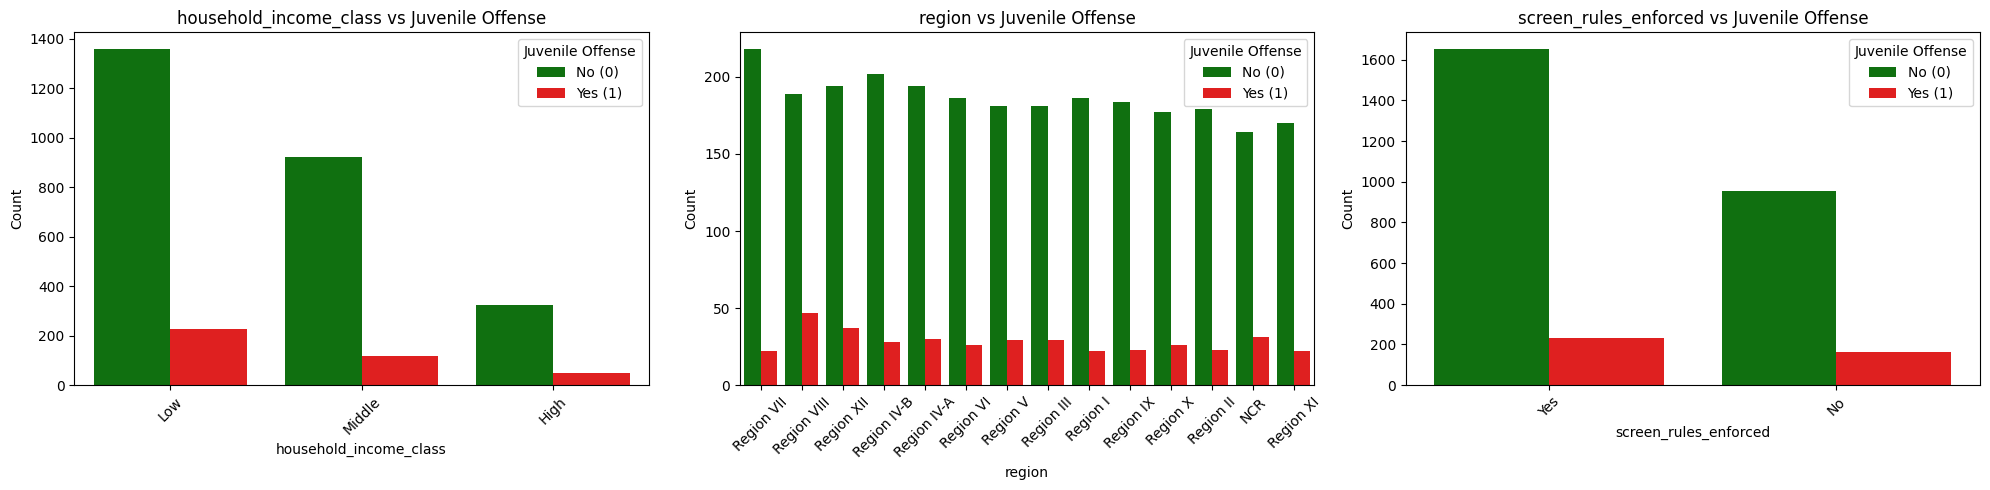

In [ ]:
cat_top3 = ["household_income_class", "region", "screen_rules_enforced"]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

palette = {
    0: "green",  # No offense
    1: "red"     # Yes offense
}

for ax, col in zip(axes, cat_top3):
    order = (
        df_type_converted[col]
        .value_counts()
        .sort_values(ascending=False)
        .index
    )

    sns.countplot(
        data=df_type_converted,
        x=col,
        hue="juvenile_offense",
        order=order,
        hue_order=[0, 1],
        palette=palette,
        ax=ax
    )

    ax.set_title(f"{col} vs Juvenile Offense")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="Juvenile Offense", labels=["No (0)", "Yes (1)"])

plt.tight_layout()
plt.show()

Insights
1. Juvenile offenses are most concentrated among low-income households, with both total counts and offense counts decreasing steadily from low to middle to high income groups.
2. Regional differences are present but relatively moderate, suggesting geography matters, but no single region overwhelmingly drives juvenile offense cases.
3. Students from households with enforced screen rules show fewer offenses in absolute terms, despite being the larger group overall, indicating a protective association.
4. Lack of screen rules is associated with a higher offense share, as the offense count is proportionally larger relative to its group size compared to those with enforced rules.
5. Socioeconomic structure and home-level controls appear more influential than location, with income class and screen rules showing stronger contrasts than regional variation.

# Ordinal Features vs Target

In [ ]:
from scipy.stats import mannwhitneyu

alpha = 0.05

ord_results = []
for col in ord_cols:
    group0 = df_type_converted[df_type_converted["juvenile_offense"] == 0][col].dropna()
    group1 = df_type_converted[df_type_converted["juvenile_offense"] == 1][col].dropna()

    stat, p = mannwhitneyu(group0, group1, alternative="two-sided")
    ord_results.append({"feature": col, "p_value": p, "decision": "Retain" if p < alpha else "Drop"})

ord_vs_target = pd.DataFrame(ord_results).sort_values("p_value")
ord_vs_target

,feature,p_value,decision
0,parental_supervision_level,0.000049,Retain
2,neighborhood_safety_index,0.542149,Drop
3,stress_level,0.789461,Drop
1,parent_digital_literacy_level,0.930398,Drop


/tmp/ipython-input-2404931017.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-2404931017.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-2404931017.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


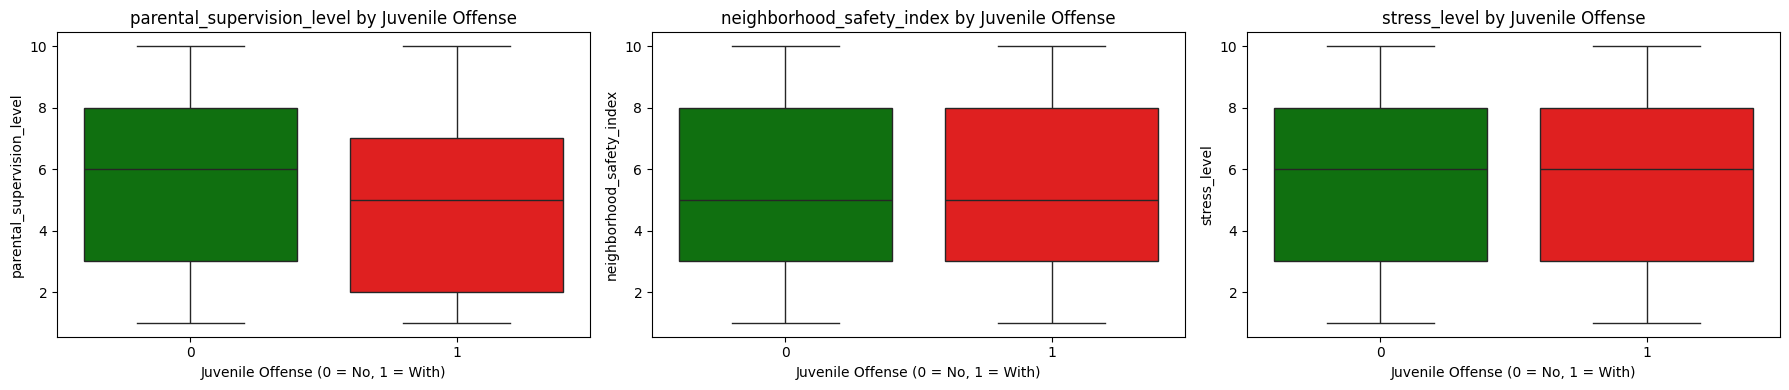

In [ ]:
ord_top3 = ["parental_supervision_level", "neighborhood_safety_index", "stress_level"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

palette = {
    "0": "green",  # No offense
    "1": "red"     # With offense
}

for ax, col in zip(axes, ord_top3):
    sns.boxplot(
        data=df_type_converted,
        x="juvenile_offense",
        y=col,
        order=["0", "1"],
        palette=palette,
        ax=ax
    )
    ax.set_title(f"{col} by Juvenile Offense")
    ax.set_xlabel("Juvenile Offense (0 = No, 1 = With)")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()


Insights
1. Lower parental supervision is associated with juvenile offenses, with the offense group showing a slightly lower median supervision level than the non-offense group.
2. Neighborhood safety differs only marginally between groups, suggesting it plays a secondary role compared to household-level factors.
3. Stress levels are broadly similar across offense and non-offense groups, indicating stress alone is not a strong standalone discriminator.
4. All three variables show substantial overlap between groups, implying no single factor is sufficient to explain juvenile offense behavior in isolation.
5. Juvenile offense risk appears to emerge from combined effects, reinforcing the need for multivariate modeling rather than one-variable thresholds.

# Numerical Features vs Target

In [ ]:
corr_threshold = 0.05

num_corr_df = (
    df_type_converted[num_cols + ["juvenile_offense"]]
    .corr(numeric_only=True)["juvenile_offense"]
    .drop("juvenile_offense")
    .rename("correlation")
    .reset_index()
    .rename(columns={"index": "feature"})
)

num_corr_df["decision"] = num_corr_df["correlation"].abs().apply(
    lambda x: "Retain" if x >= corr_threshold else "Drop"
)

num_corr_df = num_corr_df.sort_values(by="correlation", key=abs, ascending=False)
num_corr_df

,feature,correlation,decision
4,daily_screen_time_hours,0.068039,Retain
5,social_media_time_hours,0.065781,Retain
1,parent_screen_time_hours,0.063106,Retain
3,school_grade_average,0.023314,Drop
0,age,-0.011883,Drop
2,school_attendance_rate,-0.009051,Drop


/tmp/ipython-input-1783248388.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipython-input-1783248388.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipython-input-1783248388.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


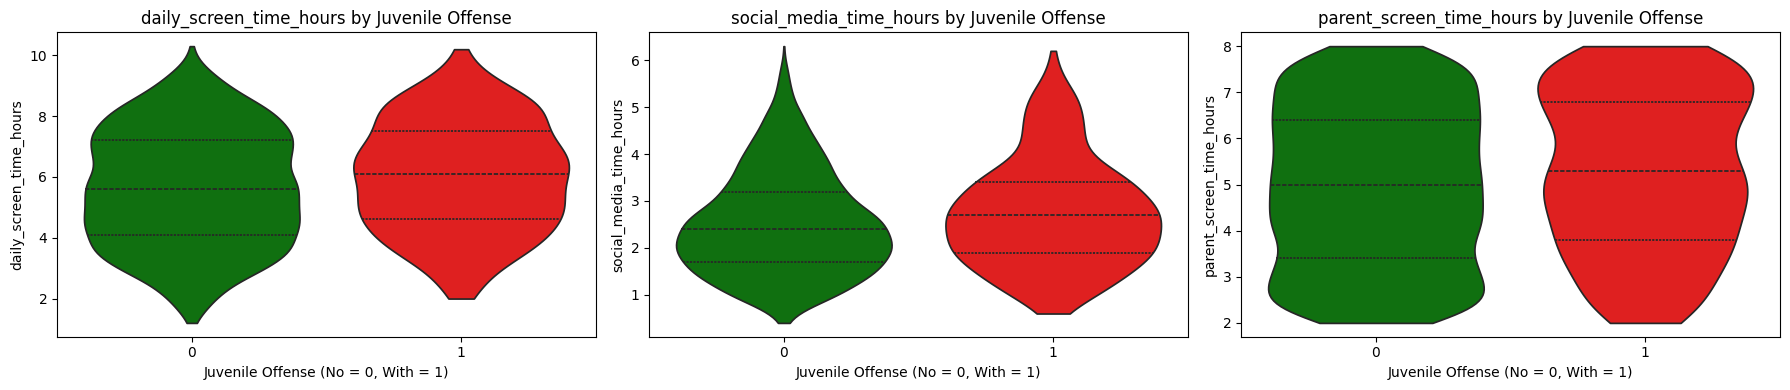

In [ ]:
num_top3 = [
    "daily_screen_time_hours",
    "social_media_time_hours",
    "parent_screen_time_hours"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

palette = {
    "0": "green",  # No offense
    "1": "red"     # With offense
}

for ax, col in zip(axes, num_top3):
    sns.violinplot(
        data=df_type_converted,
        x="juvenile_offense",
        y=col,
        order=["0", "1"],
        palette=palette,
        inner="quartile",
        cut=0,
        ax=ax
    )
    ax.set_title(f"{col} by Juvenile Offense")
    ax.set_xlabel("Juvenile Offense (No = 0, With = 1)")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

Insights
1. Students with juvenile offenses exhibit higher daily screen time, with the distribution shifted upward and a higher median compared to non-offending peers.
2. Social media time is modestly higher among the offense group, showing a rightward shift that suggests increased engagement rather than extreme usage.
3. Parent screen time is also higher in households with juvenile offenses, indicating a shared digital-use environment rather than an isolated student behavior.
4. Distributions overlap substantially across all three variables, implying screen time alone is insufficient to explain juvenile offense outcomes.
5. The pattern points to cumulative digital exposure effects, where combined student and parent screen habits may jointly relate to juvenile offense risk.

# Selected Columns

In [ ]:
cat_cols_selected = cat_vs_target.loc[cat_vs_target["decision"] == "Retain", "feature"].tolist()
ord_cols_selected = ord_vs_target.loc[ord_vs_target["decision"] == "Retain", "feature"].tolist()
num_cols_selected = num_corr_df.loc[num_corr_df["decision"] == "Retain", "feature"].tolist()

drop_cols_selected = (
    cat_vs_target.loc[cat_vs_target["decision"] == "Drop", "feature"].tolist()
    + ord_vs_target.loc[ord_vs_target["decision"] == "Drop", "feature"].tolist()
    + num_corr_df.loc[num_corr_df["decision"] == "Drop", "feature"].tolist()
)

selected_cols = cat_cols_selected + ord_cols_selected + num_cols_selected + target_col
df_selected = df_type_converted[selected_cols].copy()
df_selected.head()

,household_income_class,parental_supervision_level,daily_screen_time_hours,social_media_time_hours,parent_screen_time_hours,juvenile_offense
0,Low,3,3.8,1.9,5.6,0
1,Low,8,4.1,1.8,7.7,0
2,Middle,5,5.3,3.1,6.1,0
3,Low,9,5.7,3.2,4.5,0
4,Middle,2,4.4,2.8,4.7,0


# Encoding Categorical Features

In [ ]:
df_encoded = pd.get_dummies(df_selected, columns=cat_cols_selected, drop_first=True, dtype=int)
df_encoded.head()

,parental_supervision_level,daily_screen_time_hours,social_media_time_hours,parent_screen_time_hours,juvenile_offense,household_income_class_Low,household_income_class_Middle
0,3,3.8,1.9,5.6,0,1,0
1,8,4.1,1.8,7.7,0,1,0
2,5,5.3,3.1,6.1,0,0,1
3,9,5.7,3.2,4.5,0,1,0
4,2,4.4,2.8,4.7,0,0,1


# Normalization

In [ ]:
df_norm = df_encoded.copy()

scale_cols = num_cols_selected + ord_cols_selected
scaler = StandardScaler()
df_norm[scale_cols] = scaler.fit_transform(df_norm[scale_cols])

df_norm.head()

,parental_supervision_level,daily_screen_time_hours,social_media_time_hours,parent_screen_time_hours,juvenile_offense,household_income_class_Low,household_income_class_Middle
0,-0.869194,-0.989397,-0.598526,0.353565,0,1,0
1,0.863419,-0.831180,-0.689152,1.566186,0,1,0
2,-0.176149,-0.198315,0.488989,0.642285,0,0,1
3,1.209941,0.012640,0.579615,-0.281617,0,1,0
4,-1.215716,-0.672964,0.217110,-0.166129,0,0,1


# Train - Test Split

In [ ]:
X = df_norm.drop(columns=target_col)
y = df_norm[target_col[0]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Model Training

In [ ]:
k_values = range(1, 31)
accuracy_scores = []

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        weights="distance"
    )
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test, y_pred))

# Evaluation

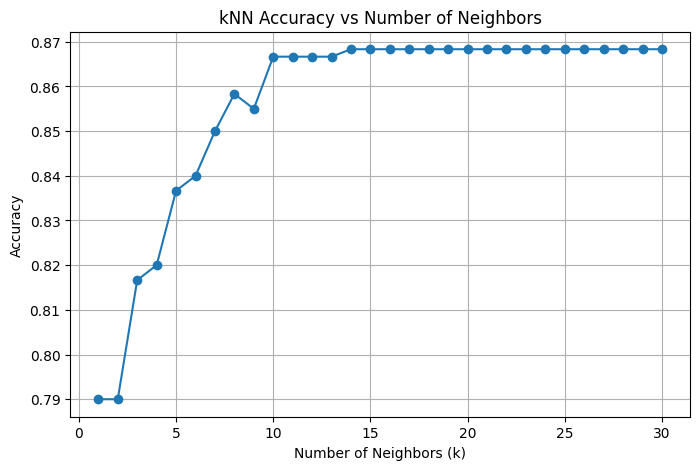

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracy_scores, marker="o")

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("kNN Accuracy vs Number of Neighbors")
plt.grid(True)
plt.show()

Insights
1. Accuracy improves rapidly as k increases from 1 to around 8–10, indicating the model benefits from smoothing out noise from very local neighbors.
2. The model reaches a performance plateau at approximately k = 10, with accuracy stabilizing around 0.87 thereafter.
3. Increasing k beyond 15 yields no meaningful accuracy gains, suggesting diminishing returns from adding more neighbors.
4. Low k values (1–3) underperform noticeably, likely due to overfitting and sensitivity to noisy observations.
5. A k value in the range of 10–15 offers the best bias–variance trade-off, delivering near-maximum accuracy with more stable predictions.